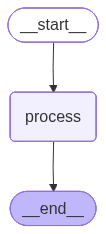

In [7]:
from typing import TypedDict,List
from langchain_core.messages import HumanMessage

from langchain_groq import ChatGroq
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv
import os

load_dotenv()

class AgentState(TypedDict):
    messages:List[HumanMessage]


llm=ChatGroq(model="llama-3.3-70b-versatile")

def process(state:AgentState)->AgentState:
    response=llm.invoke(state['messages'])
    print(f"\nAI: {response.content}")
    return state
graph=StateGraph(AgentState)
graph.add_node("process",process)
graph.add_edge(START,"process")
graph.add_edge("process",END)
agent=graph.compile()

agent

In [10]:
user_input=input("Enter: ")
agent.invoke({"messages":[HumanMessage(content=user_input)]})


AI: I'm just a language model, so I don't have feelings or emotions like humans do, but I'm functioning properly and ready to assist you with any questions or tasks you may have. How can I help you today?


{'messages': [HumanMessage(content='how are you?', additional_kwargs={}, response_metadata={})]}

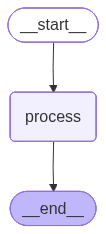

In [ ]:
import os 
from typing import TypedDict, Dict,List,Union
from langchain_core.messages import HumanMessage,AIMessage
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph,START,END
from dotenv import load_dotenv

load_dotenv()


class AgentState(TypedDict):
    messages:List[Union[HumanMessage,AIMessage]]


llm=ChatGroq(model="llama-3.3-70b-versatile")

def process(state:AgentState)->AgentState:
    """This is the first Node and it will do solve the request you input"""

    response=llm.invoke(state["messages"])
    state["messages"].append(AIMessage(content=response.content))

    print(f"\nAI: {response.content}")
    print("CURRENT STATE : ",state['messages'])
    return state

graph=StateGraph(AgentState)
graph.add_node("process",process)
graph.add_edge(START,"process")
graph.add_edge("process",END)
app=graph.compile()
app




In [12]:
conversaton_history=[]
user_input=input("Enter :")
while user_input != "exit":
    conversaton_history.append(HumanMessage(content=user_input))
    result=app.invoke({'messages':conversaton_history})
    print(result['messages'])
    conversaton_history=result['messages']
    user_input = input("Enter : ")
    


AI: Hello Asfand Yar, I'm doing well, thanks for asking. It's nice to meet you. Is there something I can help you with or would you like to chat?
[HumanMessage(content='hey how are you i am asfand yar', additional_kwargs={}, response_metadata={}), AIMessage(content="Hello Asfand Yar, I'm doing well, thanks for asking. It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool_calls=[])]

AI: You are Asfand Yar, the person I'm currently chatting with. If you'd like to tell me more about yourself, I'm all ears! What do you do, or what are your interests?
[HumanMessage(content='hey how are you i am asfand yar', additional_kwargs={}, response_metadata={}), AIMessage(content="Hello Asfand Yar, I'm doing well, thanks for asking. It's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={}, tool_calls=[], invalid_tool

In [13]:
with open("logging.txt","w") as file:
    file.write("Your Conversation Log:\n")
    for message in conversaton_history:
        if isinstance(message,HumanMessage):
            file.write(f"you: {message.content}\n")
        elif isinstance(message,AIMessage):
            file.write(f"AI: {message.content}\n\n")
    
    file.write("End of Conversation")

print("conversaton saved to logging.txt")

conversaton saved to logging.txt


In [14]:
with open("logging.txt","r") as file:
    for line in file:
        print(line)

Your Conversation Log:

you: hey how are you i am asfand yar

AI: Hello Asfand Yar, I'm doing well, thanks for asking. It's nice to meet you. Is there something I can help you with or would you like to chat?



you: who am i

AI: You are Asfand Yar, the person I'm currently chatting with. If you'd like to tell me more about yourself, I'm all ears! What do you do, or what are your interests?



you: perfect

AI: Glad I got it right. Now that we've got the introductions out of the way, is there something specific you'd like to talk about or ask me? I'm here to help or just chat if you'd like. What's on your mind, Asfand Yar?



End of Conversation


# ReAct Agent

# Objectives:
1.Learn how t create Tools in LangGraph

2.How to create a ReAct Graph

3.work with different types of Messages such as ToolMessages

4.Test out robustness of our graph

# Main Goal:

Create a robust ReAct Agent!


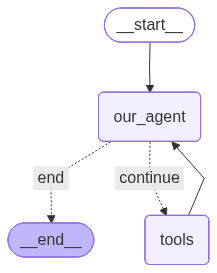

In [20]:
from typing import TypedDict,Dict,List,Annotated,Sequence
from dotenv import load_dotenv
from langgraph.graph import StateGraph,START,END
from langchain_core.messages import BaseMessage,ToolMessage,SystemMessage
from langchain_groq import ChatGroq
from langchain_core.tools import tool
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode

load_dotenv()

# Annotate - provides additional context without affecting the type itself

# Sequence- To automatically handle the state updates for the sequence such as by adding new messages to a chat history

# Reducer Function
# Rule that controls how updates from nodes are combined with the existing state
# Tells us how to merge new data into the current state
# without a reducer, updates would have replaced the existing value entirely!


#With out reducer:

# state={'messages':["hi"]}
# update={"messages":["how are you"]}
# new_state = {'messages':"how are you"}


# # With reducer:


# state={'messages':["hi"]}
# update={"messages":["how are you"]}
# new_state = {'messages':["hi""how are you"]}





class AgentState(TypedDict):
    messages:Annotated[Sequence[BaseMessage],add_messages]


@tool
def add(a:int,b:int):
    """This is an addition function that add two number together"""
    return a + b


tools=[add]

model=ChatGroq(model="llama-3.3-70b-versatile").bind_tools(tools)

def model_call(state:AgentState):
    system_prompt=SystemMessage(content=
                                "you are my AI assistant,please answer my query to the best of your ability."
                             )
    response=model.invoke([system_prompt] + state["messages"])
    return {"messages": [response]}

def should_continue(state:AgentState)->AgentState:
    messages=state['messages']
    last_message=messages[-1]
    if not last_message.tool_calls:
        return "end"
    else:
        return "continue"
    
graph = StateGraph(AgentState)
graph.add_node("our_agent",model_call)

tool_node=ToolNode(tools=tools)
graph.add_node("tools",tool_node)

graph.set_entry_point("our_agent")
graph.add_conditional_edges(
    "our_agent",
    should_continue,
    {
        "continue":"tools",
        "end":END,
    
    })

graph.add_edge("tools","our_agent")

app=graph.compile()
app


    

In [22]:
def print_stream(stream):
    for s in stream:
        message=s["messages"][-1]
        if isinstance(message,tuple):
            print(message)
        else:
            message.pretty_print()

inputs={'message':[{"user","Add 43 + 42"}]}

print_stream(app.stream(inputs,stream_mode="values"))


================================== Ai Message ==================================

I'm happy to assist you. What is your query?


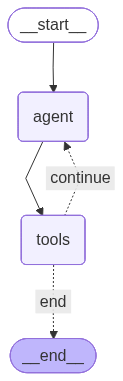

In [24]:
from typing import TypedDict,Annotated,Sequence
from langgraph.graph import StateGraph,START,END
from langgraph.graph.message import add_messages
from langgraph.prebuilt import ToolNode
from langchain_core.tools import tool
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage,HumanMessage,AIMessage,ToolMessage,SystemMessage

load_dotenv()

# This is the global variable to store document content

document_content=""

class AgentState(TypedDict):
    messages:Annotated[Sequence[BaseMessage],add_messages]

@tool
def update(content:str)->str:
    """Updates the document with the provided content"""

    global document_content
    document_content=content


    return f"Document has been updated successfully! the current content is :\n{document_content} "

@tool 
def save(filename:str)->str:
    """Save teh current document to a text file and finish the process.

    Args:
        filename:Name for the text file.

    """

    global document_content
    if not filename.endswith(".txt"):
        filename=f"{filename}.txt"

    try :
        with open(filename,"w") as file:
            file.write(document_content)
        print(f"\n Document has been saved to :{filename}")
        return f"Document has been saved successfully to '{filename}'."
    except Exception as e:
        return f"Error savign document: {str(e)}"
    
tools = [update,save]

model=ChatGroq(model="llama-3.3-70b-versatile").bind_tools(tools)

def our_agent(state:AgentState)->AgentState:
    system_prompt=SystemMessage(content=f"""

    You are Drafter, a helpful writting assistent. You are going to help user with updating and saving the following:
        - if the user wants to update or modify the content, use the 'update' tool with the complete   update content
        - if the user wants to save and finish the process you need to use the 'save' tool.
        -   make sure to allow show the current document state after modificaitons.

    The current document content is : {document_content}                                             
                               
 """)
    
    if not state['messages']:
        user_input="I'm ready to help you update a document.What would you like to create?"
        user_message=HumanMessage(content=user_input)
    
    else:
        user_input=input("\n What would you like to do with the document?")
        print(f"\n USER: {user_input}")
        user_message=HumanMessage(content=user_input)

    all_message=[system_prompt]+list(state["messages"]) + [user_message]


    response=model.invoke(all_message)

    print(f"\n Ai: {response.content}")
    if hasattr(response,"tool_calls") and response.tool_calls:
        print(f" USING TOOLS : {[tc["name"] for tc in response.tool_calls]}")
    
    return {"messages": list(state["messages"])+ [user_message,response]}

def should_countinue(state:AgentState)->AgentState:
    """Determine if we should continue or end the conversation."""
    messages=state['messages']

    if not messages:
        return "continue"
    # this looks for the most recent tool message....
    for message in reversed(messages):
        # ... and checks if tis is  a toolmessage resulting from save
        if (isinstance(message,ToolMessage) and
            "saved" in message.content.lower()and
            "document" in message.content.lower()):
            return "end"
        
        return "continue"
    
def print_message(messages):
    """Function I made to print the messages in a more readable format"""
    if not messages:
        return
    for message in messages[-3:]:
        if isinstance(message,ToolMessage):
            print(f"\n TOOL RESULT : {message.content}")



graph=StateGraph(AgentState)
graph.add_node("agent",our_agent)
graph.add_node("tools",ToolNode(tools))

    
graph.set_entry_point("agent")


graph.add_edge("agent","tools")
graph.add_conditional_edges(
    "tools",
    should_continue,
    {
        "continue":"agent",
        "end":END
    },
)


app=graph.compile()
app




In [25]:
def run_document_agent():
    print("\n ===== Drafter =====")
    state={"messages": []}
    for step in app.stream(state,stream_mode="values"):
        if "messages" in step:
            print_messages(step["messages"])
    print(f"\n === Drift Finish ===")

In [ ]:
"The